In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [2]:
df = pd.read_csv("C:\projects\mobile_review_recommendation\data\Raw\Mobile Reviews Sentiment null.csv", encoding= 'utf-8')
df


<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\dell\AppData\Local\Temp\ipykernel_6288\2978174166.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv("C:\projects\mobile_review_recommendation\data\Raw\Mobile Reviews Sentiment null.csv", encoding= 'utf-8')


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,A$804.93,AUD,1.53,4.0,...,English,8/17/2023,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,A$1395.13,AUD,1.53,3.0,...,English,9/23/2023,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,د.إ4240.02,AED,3.67,NaN,...,English,4/4/2023,True,2,3,4,4,5,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,NaN,USD,1.00,3.0,...,English,7/11/2025,True,1,2,2,1,3,6,NaN


In [3]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [4]:
df.shape

(50000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  object 
 11  country               50000 non-null  object 
 12  language              50000 non-null  object 
 13  review_date           50000 non-null  object 
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating

In [6]:
df.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,47550.00000,50000.000000,47547.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.89277,12.057946,3.123415,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,310.32722,26.553332,1.249067,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.02000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.75500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,637.58500,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.45750,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.89000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


### Handling missing values

In [7]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [8]:
df.duplicated().sum()

0

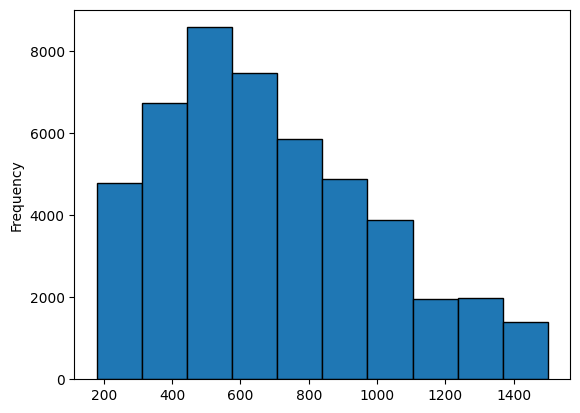

In [9]:
df['price_usd'].plot(kind= 'hist', edgecolor= 'black')
plt.show()

In [10]:
df['price_usd']=  df['price_usd'].fillna(df['price_usd'].median())

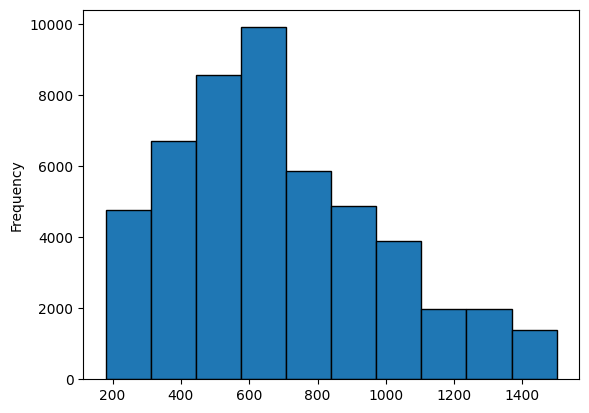

In [11]:
df['price_usd'].plot(kind= 'hist', edgecolor= 'black')
plt.show()

In [12]:
df.columns

Index(['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd',
       'price_local', 'currency', 'exchange_rate_to_usd', 'rating',
       'sentiment', 'country', 'language', 'review_date', 'verified_purchase',
       'battery_life_rating', 'camera_rating', 'performance_rating',
       'design_rating', 'display_rating', 'helpful_votes', 'source'],
      dtype='object')

In [13]:
df = df.drop(columns=['review_id', 'price_local', 'exchange_rate_to_usd'], axis = 1)

In [15]:
df.columns

Index(['customer_name', 'age', 'brand', 'model', 'price_usd', 'currency',
       'rating', 'sentiment', 'country', 'language', 'review_date',
       'verified_purchase', 'battery_life_rating', 'camera_rating',
       'performance_rating', 'design_rating', 'display_rating',
       'helpful_votes', 'source'],
      dtype='object')

In [16]:
df['rating'].value_counts()

rating
4.0    13315
3.0    11856
2.0     9305
5.0     7000
1.0     6071
Name: count, dtype: int64

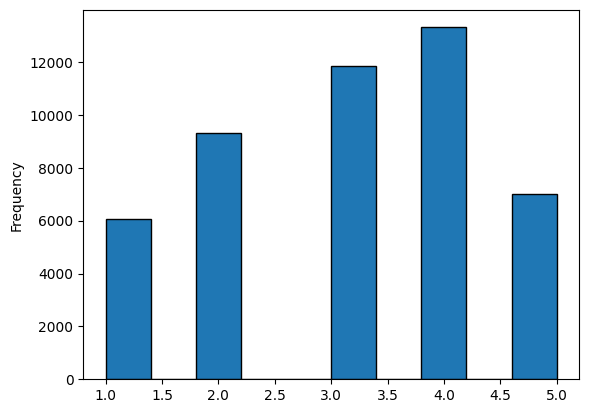

In [17]:
df['rating'].plot(kind='hist', edgecolor='black')
plt.show()

In [18]:
df['rating'] = df['rating'].fillna(df['rating'].median())

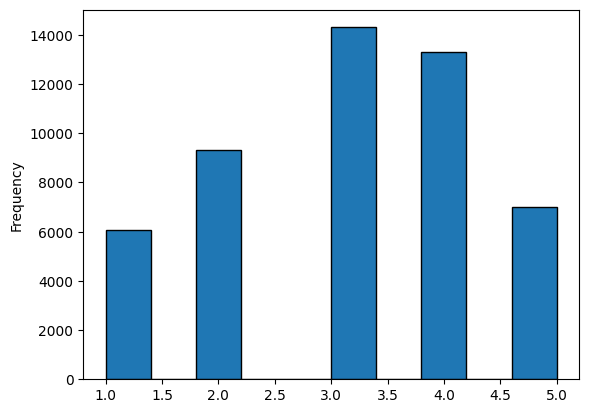

In [19]:
df['rating'].plot(kind='hist', edgecolor='black')
plt.show()

In [20]:
df.isna().sum()

customer_name             0
age                       0
brand                     0
model                     0
price_usd                 0
currency                  0
rating                    0
sentiment              2445
country                   0
language                  0
review_date               0
verified_purchase         0
battery_life_rating       0
camera_rating             0
performance_rating        0
design_rating             0
display_rating            0
helpful_votes             0
source                 2448
dtype: int64

In [21]:
df['sentiment'].value_counts()

sentiment
Positive    26282
Neutral     11931
Negative     9342
Name: count, dtype: int64

In [23]:
df[['rating', 'sentiment']].value_counts(
)

rating  sentiment
4.0     Positive     11531
3.0     Positive      7358
5.0     Positive      6614
3.0     Neutral       4883
2.0     Neutral       4612
1.0     Negative      4461
2.0     Negative      3467
3.0     Negative      1360
1.0     Neutral       1242
4.0     Neutral       1118
2.0     Positive       754
5.0     Neutral         76
4.0     Negative        54
1.0     Positive        25
Name: count, dtype: int64

In [24]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
Positive    55.266533
Neutral     25.088844
Negative    19.644622
Name: proportion, dtype: float64

In [25]:
proportions = df['sentiment'].value_counts(normalize=True)
missing_mask = df['sentiment'].isnull()
df.loc[missing_mask, ['sentiment']] = np.random.choice(
    proportions.index, missing_mask.sum(), p= proportions.values
)

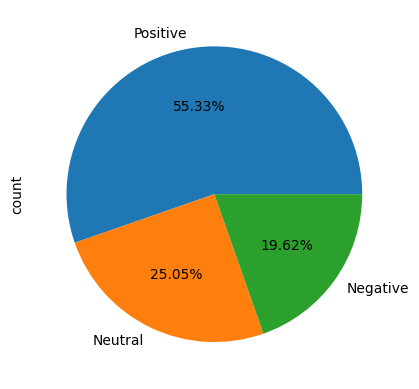

In [26]:
df['sentiment'].value_counts().plot(kind= 'pie', autopct= '%.2f%%')
plt.show()

In [27]:
df['sentiment'].value_counts()

sentiment
Positive    27664
Neutral     12527
Negative     9809
Name: count, dtype: int64

In [28]:
df['source'].value_counts()

source
eBay          9573
AliExpress    9531
Amazon        9513
Flipkart      9481
BestBuy       9454
Name: count, dtype: int64

In [29]:
proportions = df['source'].value_counts(normalize=True)
missing_mask = df['source'].isnull()
df.loc[missing_mask, ['source']] = np.random.choice(
    proportions.index, missing_mask.sum(), p= proportions.values
) 


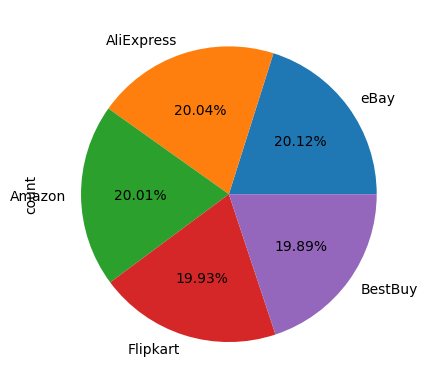

In [30]:
df['source'].value_counts().plot(kind= 'pie', autopct= '%.2f%%')
plt.show()

In [31]:
df.isna().sum()

customer_name          0
age                    0
brand                  0
model                  0
price_usd              0
currency               0
rating                 0
sentiment              0
country                0
language               0
review_date            0
verified_purchase      0
battery_life_rating    0
camera_rating          0
performance_rating     0
design_rating          0
display_rating         0
helpful_votes          0
source                 0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_name        50000 non-null  object 
 1   age                  50000 non-null  int64  
 2   brand                50000 non-null  object 
 3   model                50000 non-null  object 
 4   price_usd            50000 non-null  float64
 5   currency             50000 non-null  object 
 6   rating               50000 non-null  float64
 7   sentiment            50000 non-null  object 
 8   country              50000 non-null  object 
 9   language             50000 non-null  object 
 10  review_date          50000 non-null  object 
 11  verified_purchase    50000 non-null  bool   
 12  battery_life_rating  50000 non-null  int64  
 13  camera_rating        50000 non-null  int64  
 14  performance_rating   50000 non-null  int64  
 15  design_rating        50000 non-null 

In [33]:
df['review_date']= pd.to_datetime(df['review_date'])

In [34]:
df = df.drop(['currency'], axis=1)

In [35]:
cat_cols = df.select_dtypes(include='object')

In [36]:
cat_cols

,customer_name,brand,model,sentiment,country,language,source
0,Aryan Maharaj,Realme,Realme 12 Pro,Negative,India,Hindi,Amazon
1,Davi Miguel Sousa,Realme,Realme 12 Pro,Positive,Brazil,Portuguese,Flipkart
2,Pahal Balay,Google,Pixel 6,Positive,India,Hindi,AliExpress
3,David Guzman,Xiaomi,Redmi Note 13,Positive,UAE,English,Amazon
4,Yago Leão,Motorola,Edge 50,Neutral,Brazil,Portuguese,BestBuy
...,...,...,...,...,...,...,...
49995,Rebecca Pratt,Realme,Realme 12 Pro,Positive,Australia,English,BestBuy
49996,Dr. Tiffany Patterson,Samsung,Galaxy Note 20,Neutral,Australia,English,AliExpress
49997,Alexandra Singh,Apple,iPhone SE,Positive,UAE,English,Amazon
49998,Robert Morris,Realme,Realme Narzo 70,Positive,USA,English,Amazon


In [37]:
for col in cat_cols:
    df[col]= df[col].str.lower()
    df[col]= df[col].str.strip()


In [38]:
df['review_date']= pd.to_datetime(df['review_date'])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_name        50000 non-null  object        
 1   age                  50000 non-null  int64         
 2   brand                50000 non-null  object        
 3   model                50000 non-null  object        
 4   price_usd            50000 non-null  float64       
 5   rating               50000 non-null  float64       
 6   sentiment            50000 non-null  object        
 7   country              50000 non-null  object        
 8   language             50000 non-null  object        
 9   review_date          50000 non-null  datetime64[ns]
 10  verified_purchase    50000 non-null  bool          
 11  battery_life_rating  50000 non-null  int64         
 12  camera_rating        50000 non-null  int64         
 13  performance_rating   50000 non-

### Outliers detection

In [41]:
num_cols = df.select_dtypes(exclude=['object', 'datetime64[ns]', 'bool'])

In [42]:
num_cols

,age,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
0,45,337.31,2.0,1,1,3,2,1,1
1,18,307.78,4.0,3,2,4,3,2,5
2,27,864.53,4.0,3,5,3,2,4,8
3,19,660.94,3.0,1,3,2,1,2,3
4,38,792.13,3.0,3,3,2,2,1,0
...,...,...,...,...,...,...,...,...,...
49995,18,526.10,4.0,3,3,4,3,5,4
49996,28,911.85,3.0,3,2,4,1,3,2
49997,21,1155.32,3.0,2,3,4,4,5,4
49998,31,459.04,3.0,1,2,2,1,3,6


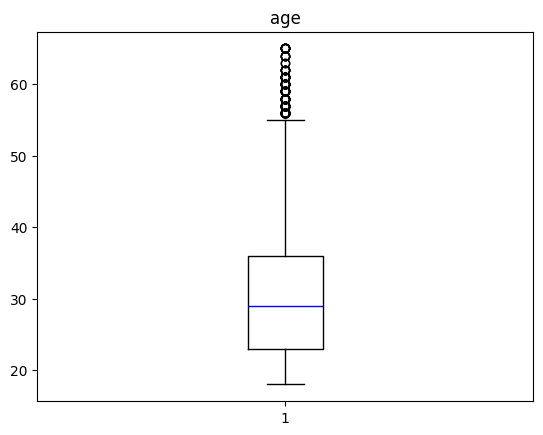

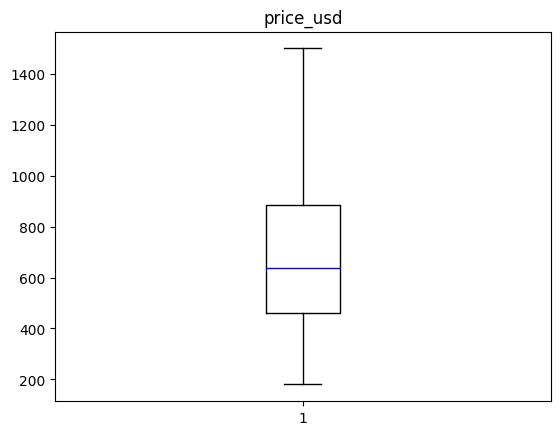

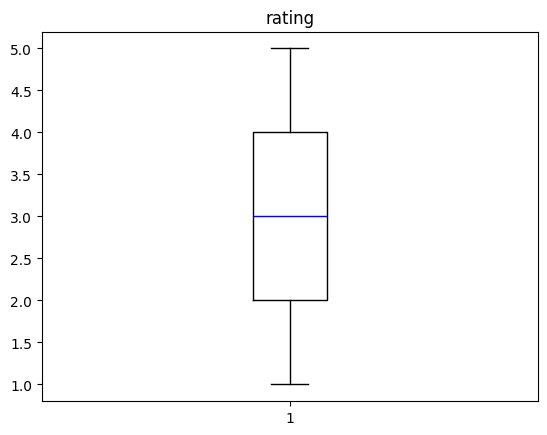

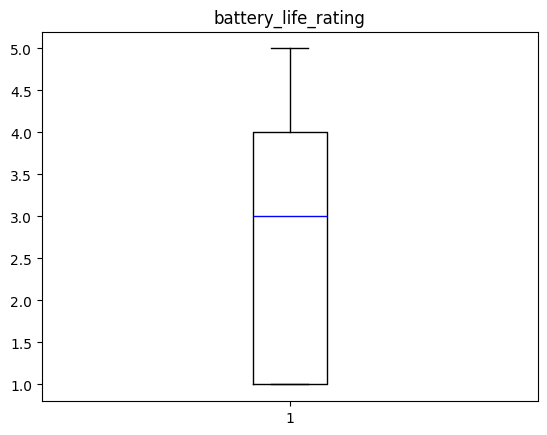

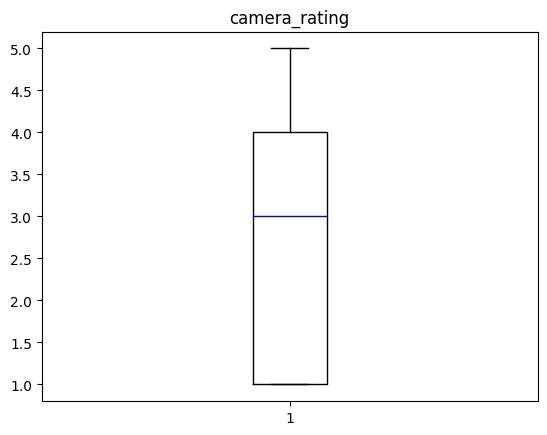

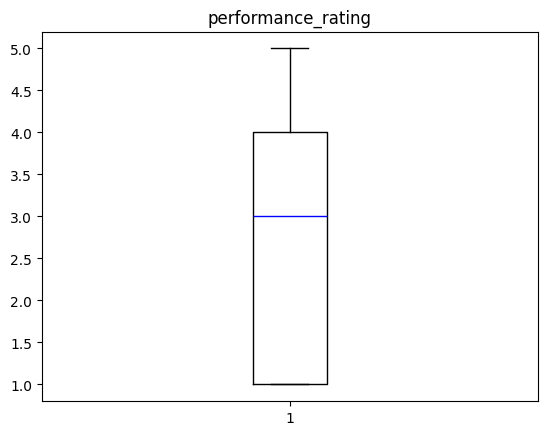

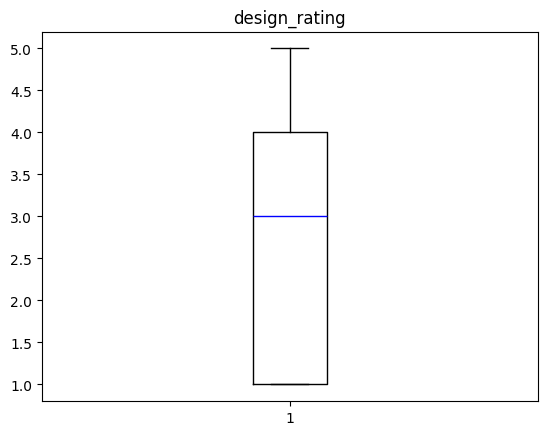

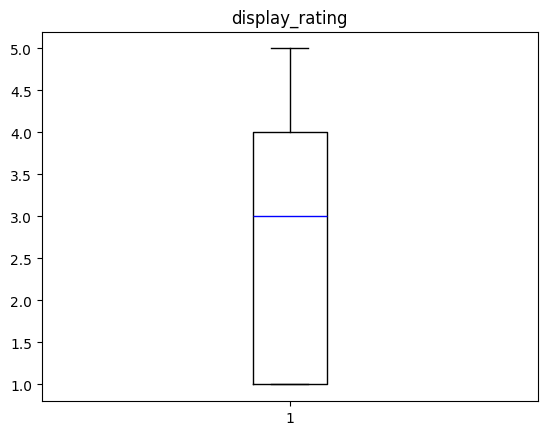

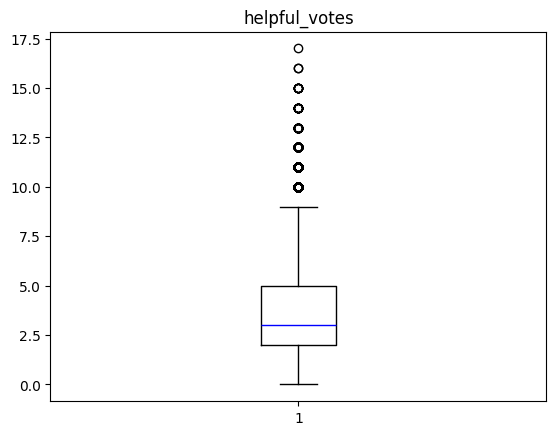

In [43]:
for col in num_cols:
    plt.boxplot(df[col], medianprops={'color': 'blue'})
    plt.title(col)
    plt.show()

### Bivariate Analysis

In [44]:
num_cols

,age,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
0,45,337.31,2.0,1,1,3,2,1,1
1,18,307.78,4.0,3,2,4,3,2,5
2,27,864.53,4.0,3,5,3,2,4,8
3,19,660.94,3.0,1,3,2,1,2,3
4,38,792.13,3.0,3,3,2,2,1,0
...,...,...,...,...,...,...,...,...,...
49995,18,526.10,4.0,3,3,4,3,5,4
49996,28,911.85,3.0,3,2,4,1,3,2
49997,21,1155.32,3.0,2,3,4,4,5,4
49998,31,459.04,3.0,1,2,2,1,3,6


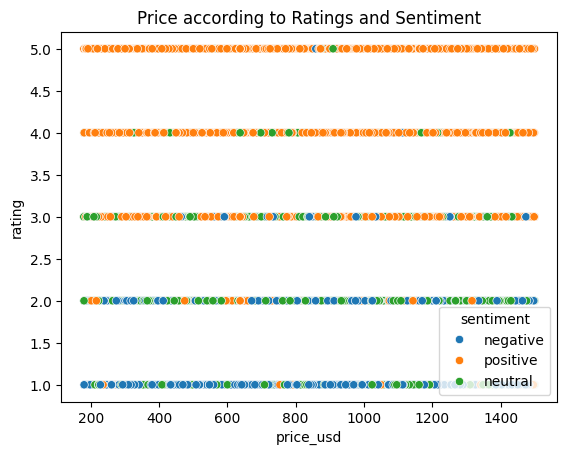

In [45]:
sns.scatterplot(x= num_cols['price_usd'], y= num_cols['rating'], hue= df['sentiment'])
plt.title('Price according to Ratings and Sentiment')
plt.show()

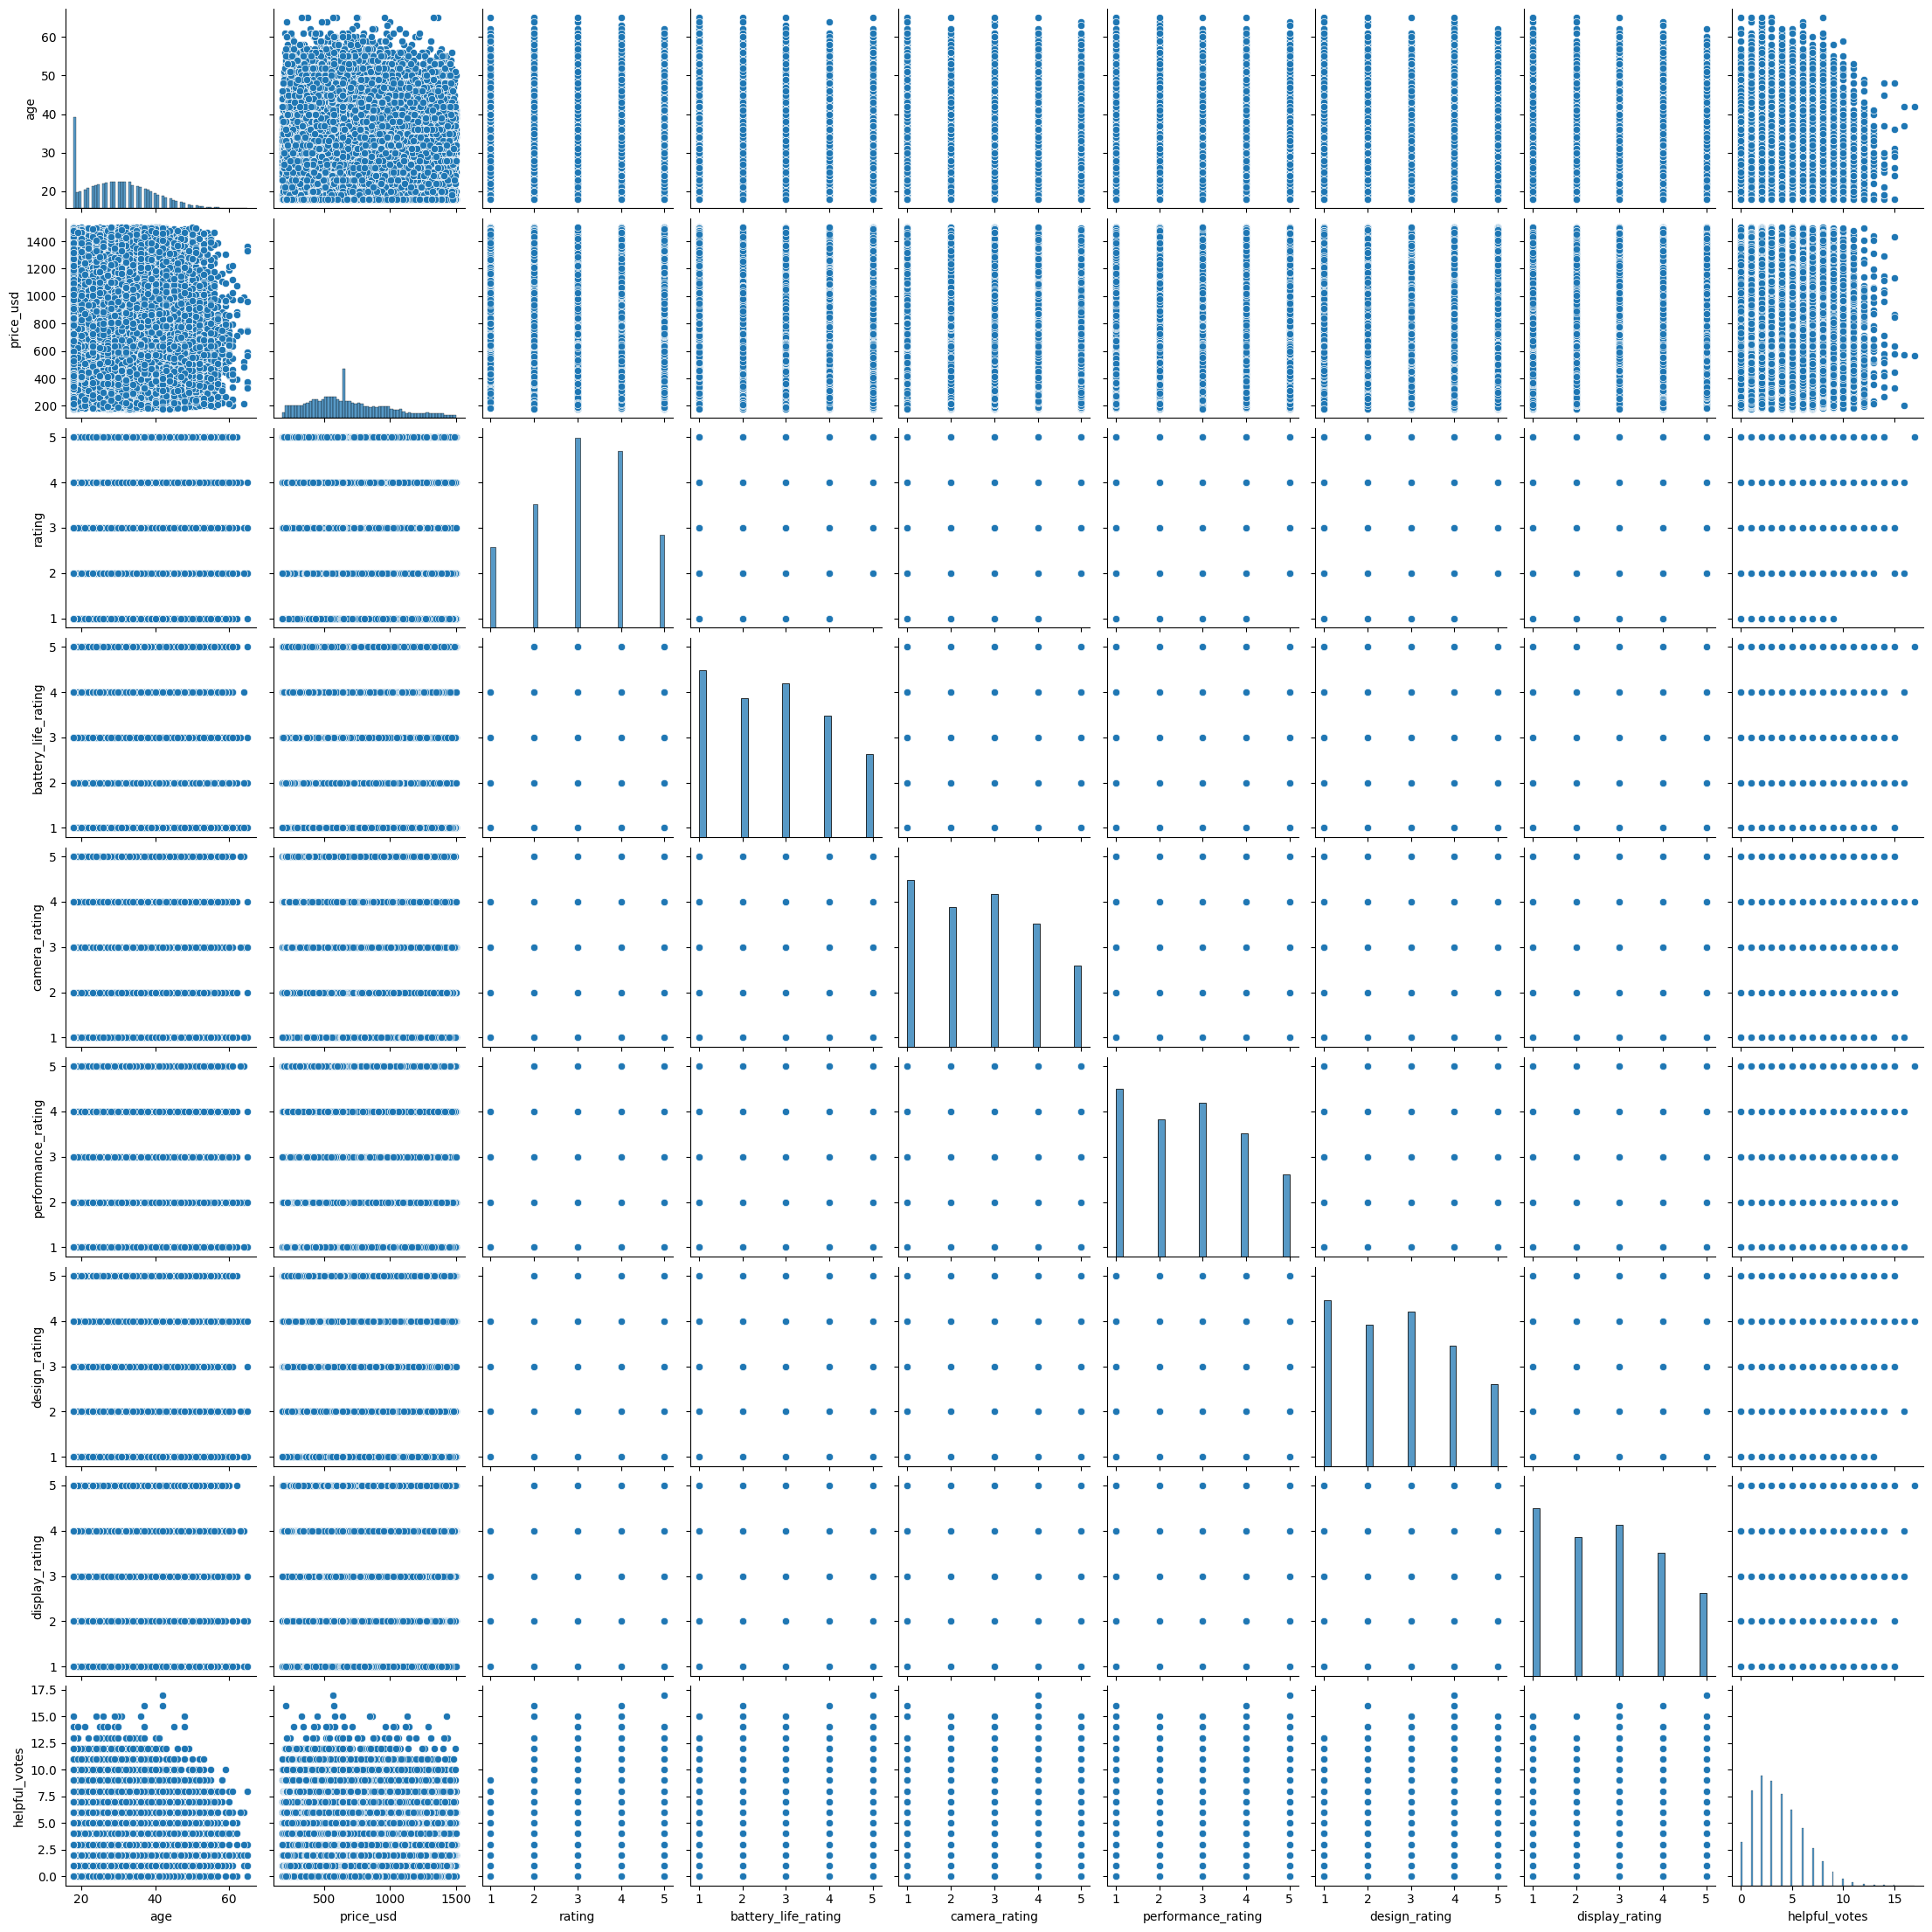

In [46]:
sns.pairplot(num_cols)
plt.show()

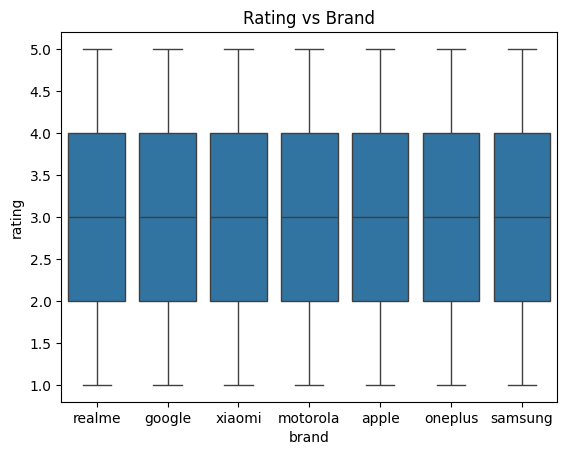

In [47]:
sns.boxplot(data= df, x=df['brand'], y=df['rating'])
plt.title("Rating vs Brand")
plt.show()

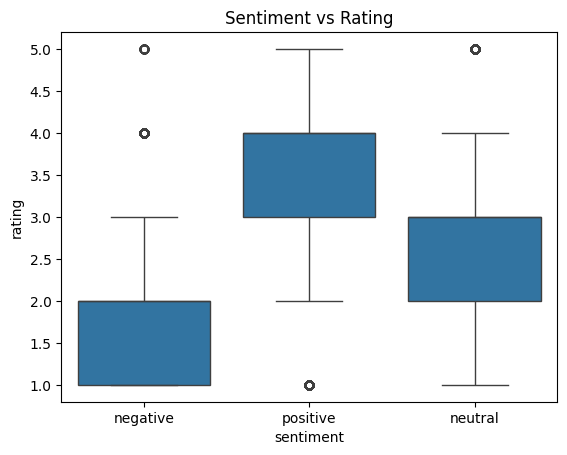

In [48]:
sns.boxplot(data= df, x= df['sentiment'], y= df['rating'])
plt.title("Sentiment vs Rating")
plt.show()

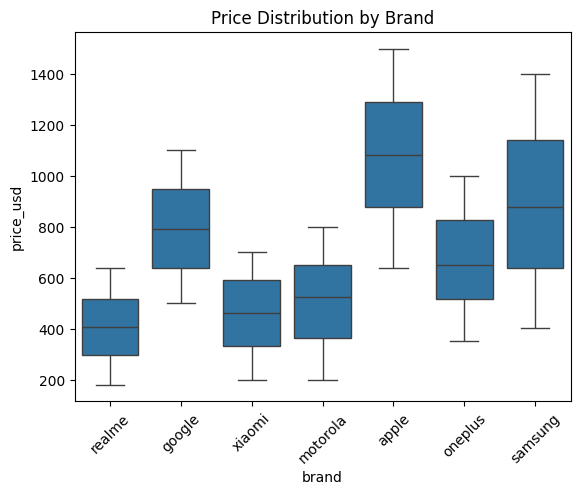

In [49]:
sns.boxplot(data=df, x='brand', y='price_usd')
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand')
plt.show()

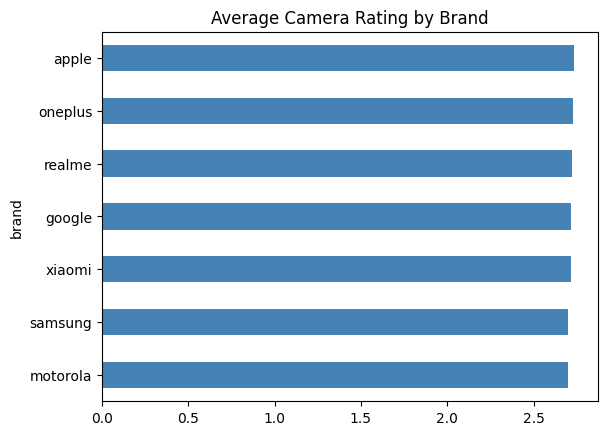

In [50]:
df.groupby('brand')['camera_rating'].mean().sort_values().plot(
    kind='barh', color='steelblue')
plt.title('Average Camera Rating by Brand')
plt.show()

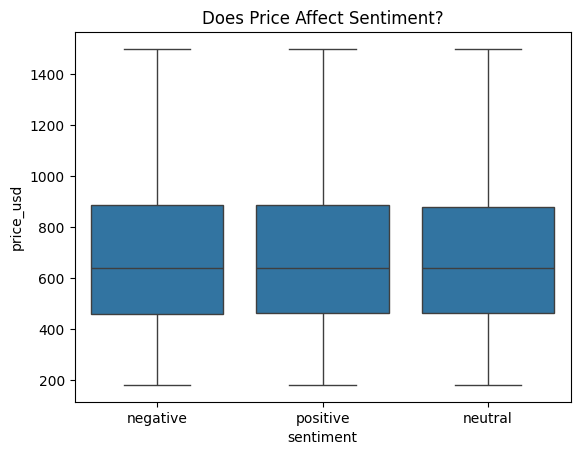

In [51]:
sns.boxplot(data=df, x='sentiment', y='price_usd')
plt.title('Does Price Affect Sentiment?')
plt.show()

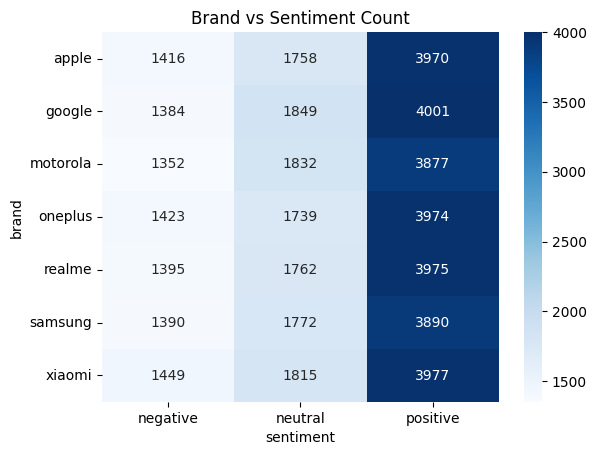

In [52]:
ct = pd.crosstab(df['brand'], df['sentiment'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Brand vs Sentiment Count')
plt.show()

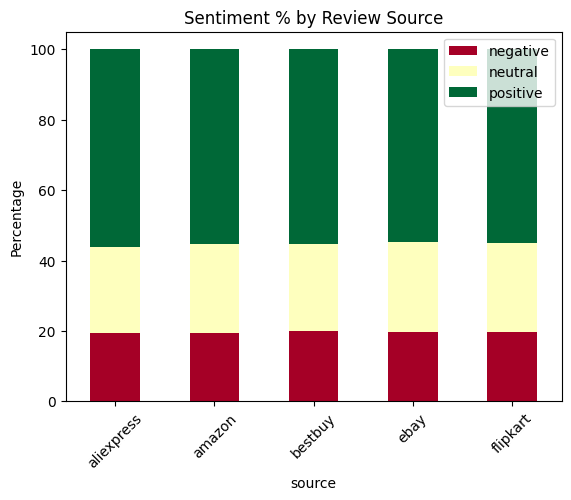

In [53]:
ct2 = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, colormap='RdYlGn')
plt.title('Sentiment % by Review Source')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [54]:
df['verified_purchase'].value_counts(
)

verified_purchase
True     40070
False     9930
Name: count, dtype: int64

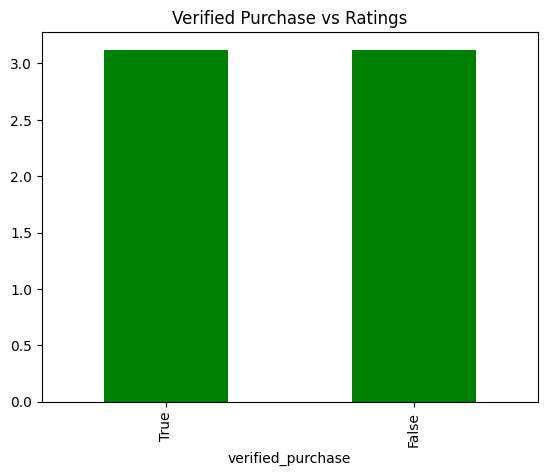

In [55]:
df.groupby('verified_purchase')['rating'].mean().sort_values().plot(
    kind= 'bar', color= 'green')
plt.title("Verified Purchase vs Ratings")
plt.show()

### Multivariate Analysis

In [56]:
num_cols.corr()

,age,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
age,1.000000,0.002454,0.008021,0.005374,0.008937,0.004708,0.010163,0.009176,-0.005121
price_usd,0.002454,1.000000,0.004332,0.002812,0.002528,-0.003381,0.003967,0.000488,0.003412
rating,0.008021,0.004332,1.000000,0.743205,0.741387,0.736331,0.736846,0.738232,0.449026
battery_life_rating,0.005374,0.002812,0.743205,1.000000,0.588938,0.584341,0.586143,0.584415,0.355964
camera_rating,0.008937,0.002528,0.741387,0.588938,1.000000,0.579975,0.580692,0.581909,0.355280
performance_rating,0.004708,-0.003381,0.736331,0.584341,0.579975,1.000000,0.576115,0.580550,0.353260
design_rating,0.010163,0.003967,0.736846,0.586143,0.580692,0.576115,1.000000,0.579132,0.352643
display_rating,0.009176,0.000488,0.738232,0.584415,0.581909,0.580550,0.579132,1.000000,0.352423
helpful_votes,-0.005121,0.003412,0.449026,0.355964,0.355280,0.353260,0.352643,0.352423,1.000000


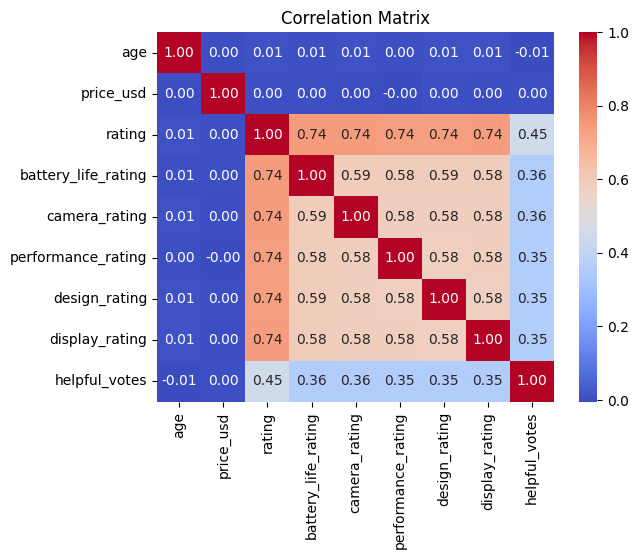

In [57]:
sns.heatmap(data= num_cols.corr(), annot= True, cmap= 'coolwarm',fmt= '.2f')
plt.title("Correlation Matrix")
plt.show()

In [58]:
df.columns

Index(['customer_name', 'age', 'brand', 'model', 'price_usd', 'rating',
       'sentiment', 'country', 'language', 'review_date', 'verified_purchase',
       'battery_life_rating', 'camera_rating', 'performance_rating',
       'design_rating', 'display_rating', 'helpful_votes', 'source'],
      dtype='object')

In [203]:
features_for_clustering= ['price_usd', 'rating', 'battery_life_rating', 'camera_rating', 
                          'performance_rating', 'design_rating', 'display_rating']

features_to_encode = ['sentiment', 'verified_purchase', 'source']

aggregate_by = ['brand', 'model']

In [204]:
df['brand'] = df['brand'].str.strip().str.title()
df['model'] = df['model'].str.strip().str.title()

In [205]:
df_model = df.groupby(['brand', 'model']).agg({'price_usd': 'mean', 'battery_life_rating': 'mean', 'camera_rating' :'mean', 
                                               'performance_rating': 'mean', 'design_rating'  : 'mean', 'display_rating': 'mean'}).reset_index()

### Scaling

In [206]:
from sklearn.preprocessing import StandardScaler

In [207]:
x_price= df_model[['price_usd']].values

In [208]:
scaler = StandardScaler()
scaled = scaler.fit_transform(x_price)

### PCA

In [209]:
from sklearn.decomposition import PCA

In [210]:
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(scaled)

In [211]:
x_pca.shape

(22, 1)

In [145]:
# Elbow Method

In [212]:
from sklearn.cluster import KMeans

In [213]:
inertia = []

for k in range(1,11):
    Kmeans= KMeans(n_clusters=k, random_state=42)
    Kmeans.fit(x_pca)
    inertia.append(Kmeans.inertia_)

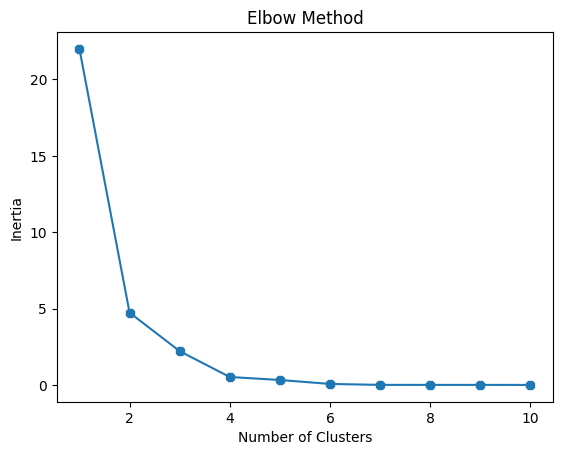

In [214]:
plt.plot(range(1,11), inertia, marker='8')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [149]:
# Silhouette Score

In [215]:
from sklearn.metrics import silhouette_score

In [216]:
silhouette_scores=[]

for k in range(2,11):
    Kmeans= KMeans(n_clusters=k, random_state=42)
    labels= Kmeans.fit_predict(x_pca)

    score = silhouette_score(x_pca, labels)
    silhouette_scores.append(score)
    print(k, score)

2 0.6590623488419776
3 0.7025619796859517
4 0.7868413004521551
5 0.7739514005197723
6 0.8640441345190525
7 0.9550253695279495
8 0.9257989381074068
9 0.8343080363888837
10 0.7785051640383686


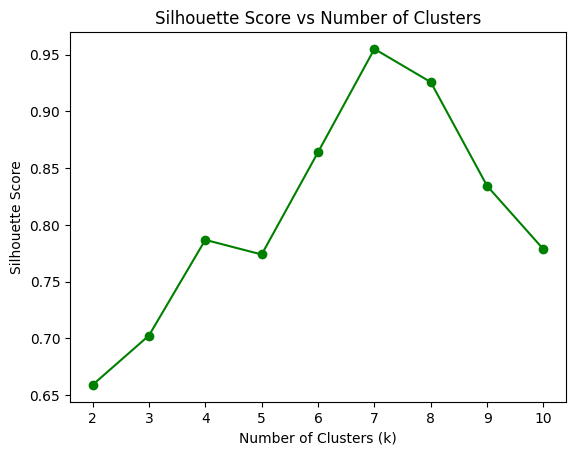

In [217]:
plt.plot(range(2, 11),silhouette_scores,marker='o', color= 'green')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

### KMeans Clustering

In [218]:
Kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = Kmeans.fit_predict(x_pca)

In [219]:
df_model['clusters'] = cluster_labels

In [220]:
df_model.groupby('clusters')[
    [
        'price_usd']
].mean()

,price_usd
clusters,
0,465.766341
1,849.030404
2,1080.221932
3,670.310638


In [221]:
avg_price       =df_model.groupby('clusters')['price_usd'].mean()
sorted_clusters = avg_price.sort_values().index.tolist()

label_map = {
    sorted_clusters[0]: 'Budget',        
    sorted_clusters[1]: 'Affordable',    
    sorted_clusters[2]: 'Mid-Range',    
    sorted_clusters[3]: 'Premium'   
}

In [222]:
df_model['segment'] = df_model['clusters'].map(label_map)
print(label_map)

{0: 'Budget', 3: 'Affordable', 1: 'Mid-Range', 2: 'Premium'}


In [223]:
df.head()

,customer_name,age,brand,model,price_usd,rating,sentiment,country,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,clusters,segment
0,aryan maharaj,45,Realme,Realme 12 Pro,337.31,2.0,negative,india,hindi,2023-11-06,True,1,1,3,2,1,1,amazon,0,Budget
1,davi miguel sousa,18,Realme,Realme 12 Pro,307.78,4.0,positive,brazil,portuguese,2023-03-30,True,3,2,4,3,2,5,flipkart,0,Budget
2,pahal balay,27,Google,Pixel 6,864.53,4.0,positive,india,hindi,2022-12-07,True,3,5,3,2,4,8,aliexpress,1,Mid-Range
3,david guzman,19,Xiaomi,Redmi Note 13,660.94,3.0,positive,uae,english,2025-03-11,False,1,3,2,1,2,3,amazon,2,Affordable
4,yago leão,38,Motorola,Edge 50,792.13,3.0,neutral,brazil,portuguese,2023-09-29,True,3,3,2,2,1,0,bestbuy,1,Mid-Range


In [256]:
print(df_model.groupby('segment')['price_usd'].agg(
    ['min', 'max', 'mean', 'count']).round(2))

                min      max     mean  count
segment                                     
Affordable   668.51   671.23   670.31      3
Budget       404.10   515.42   465.77      8
Mid-Range    791.93   894.14   849.03      7
Premium     1076.76  1083.94  1080.22      4


In [225]:
for seg in ['Budget', 'Affordable', 'Mid-Range', 'Premium']:
    phones = df_model[df_model['segment'] == seg][
        ['brand', 'model', 'price_usd']]
    print(f"\n── {seg} ──────────────────")
    print(phones.sort_values('price_usd').to_string(index=False))


── Budget ──────────────────
   brand           model  price_usd
  Realme Realme Narzo 70 404.095803
  Realme   Realme 12 Pro 407.677332
  Xiaomi         Poco X6 457.488480
  Xiaomi       Mi 13 Pro 458.966419
  Xiaomi   Redmi Note 13 459.736872
Motorola    Moto G Power 510.950551
Motorola         Razr 40 511.799777
Motorola         Edge 50 515.415495

── Affordable ──────────────────
  brand          model  price_usd
Oneplus     Oneplus 12 668.509559
Oneplus Oneplus Nord 3 671.190616
Oneplus    Oneplus 11R 671.231741

── Mid-Range ──────────────────
  brand          model  price_usd
 Google        Pixel 8 791.928209
 Google       Pixel 7A 799.317202
 Google        Pixel 6 801.082415
Samsung     Galaxy S24 882.407357
Samsung  Galaxy Z Flip 886.563025
Samsung Galaxy Note 20 887.773167
Samsung     Galaxy A55 894.141451

── Premium ──────────────────
brand         model   price_usd
Apple Iphone 15 Pro 1076.756913
Apple     Iphone 14 1077.610694
Apple     Iphone Se 1082.581434
Apple     Ip

C:\Users\dell\AppData\Local\Temp\ipykernel_6288\3867743879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segment', y='price_usd',


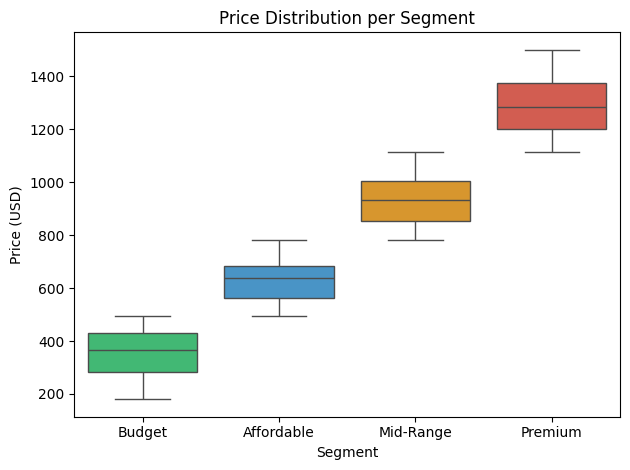

In [226]:
order = ['Budget', 'Affordable', 'Mid-Range', 'Premium']

sns.boxplot(data=df, x='segment', y='price_usd',
            order=order,
            palette=['#2ecc71','#3498db','#f39c12','#e74c3c'])

plt.title('Price Distribution per Segment')
plt.xlabel('Segment')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

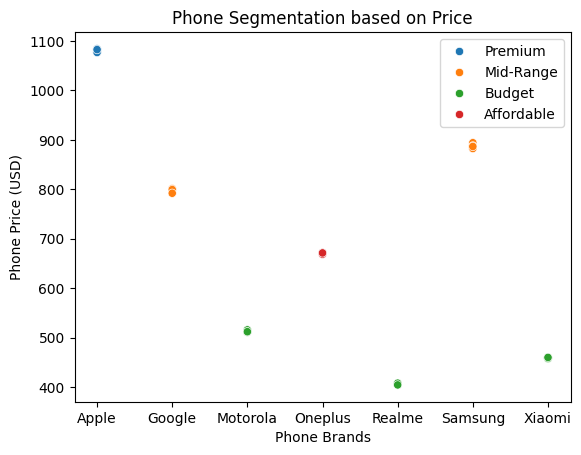

In [227]:
sns.scatterplot(data= df_model, x= 'brand', y='price_usd', hue= 'segment')
plt.xlabel("Phone Brands")
plt.ylabel("Phone Price (USD)")
plt.title("Phone Segmentation based on Price")
plt.legend()
plt.show()

### Recommendation

In [228]:
from sklearn.metrics.pairwise import cosine_similarity

In [229]:
df_model

,brand,model,price_usd,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,clusters,segment
0,Apple,Iphone 13,1083.938687,2.754952,2.754952,2.765139,2.765139,2.710243,2,Premium
1,Apple,Iphone 14,1077.610694,2.738255,2.781879,2.723714,2.773490,2.758949,2,Premium
2,Apple,Iphone 15 Pro,1076.756913,2.677635,2.707195,2.661461,2.675404,2.691021,2,Premium
3,Apple,Iphone Se,1082.581434,2.727728,2.703786,2.732183,2.690980,2.735523,2,Premium
4,Google,Pixel 6,801.082415,2.712064,2.709962,2.689786,2.706179,2.715427,1,Mid-Range
5,Google,Pixel 7A,799.317202,2.715964,2.732172,2.725689,2.721232,2.748784,1,Mid-Range
6,Google,Pixel 8,791.928209,2.731881,2.715543,2.691244,2.743611,2.737746,1,Mid-Range
7,Motorola,Edge 50,515.415495,2.674730,2.701512,2.704536,2.688553,2.707559,0,Budget
8,Motorola,Moto G Power,510.950551,2.715015,2.706083,2.716291,2.716291,2.719268,0,Budget
9,Motorola,Razr 40,511.799777,2.713152,2.683925,2.730271,2.724843,2.724008,0,Budget


In [230]:
recommend_features = ['price_usd', 'battery_life_rating', 'camera_rating', 'performance_rating',
                      'design_rating', 'display_rating']

In [231]:
df_model[recommend_features].shape

(22, 6)

In [232]:
# scaling features

In [233]:
X= df_model[recommend_features].values
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(X)

In [234]:
feature_scaled[:,0]= feature_scaled[:, 0] *3

In [235]:
print(f"Shape going into recommender: {feature_scaled.shape}")

Shape going into recommender: (22, 6)


In [236]:
# similarity matrix

In [237]:
sim_matrix = cosine_similarity(feature_scaled, dense_output=False)

In [238]:
sim_df = pd.DataFrame(sim_matrix, index=df_model['model'].str.strip().values,
                       columns=df_model['model'].str.strip().values )

In [239]:
print(f"Similarity matrix shape: {sim_df.shape}")
print(sim_df.head())

Similarity matrix shape: (22, 22)
               Iphone 13  Iphone 14  Iphone 15 Pro  Iphone Se   Pixel 6  \
Iphone 13       1.000000   0.895992       0.400245   0.754192  0.253412   
Iphone 14       0.895992   1.000000       0.397781   0.695604  0.304478   
Iphone 15 Pro   0.400245   0.397781       1.000000   0.747331  0.918723   
Iphone Se       0.754192   0.695604       0.747331   1.000000  0.644782   
Pixel 6         0.253412   0.304478       0.918723   0.644782  1.000000   

               Pixel 7A   Pixel 8   Edge 50  Moto G Power   Razr 40  ...  \
Iphone 13      0.581134  0.531448 -0.931930     -0.853398 -0.791270  ...   
Iphone 14      0.828041  0.685495 -0.866359     -0.825860 -0.813654  ...   
Iphone 15 Pro  0.240868  0.154411 -0.282292     -0.787671 -0.751760  ...   
Iphone Se      0.588247  0.408174 -0.746935     -0.941117 -0.815808  ...   
Pixel 6        0.143687  0.359124 -0.251868     -0.650643 -0.622127  ...   

               Oneplus Nord 3  Realme 12 Pro  Realme Narzo

In [ ]:
def get_recommendations(model_name, df_model, sim_df, top_n=5, same_segment_only = False):

    if model_name not in sim_df.index:
        print(f"'{model_name}' not found")
        print(f"Available: {list(sim_df.index)}")
        return None
    
    selected_segment= df_model[df_model['model']== model_name]['segment'].values[0]

    segment_order = ['Budget', 'Affordable', 'Mid-Range', 'Premium']
        
    scores = sim_df[model_name].sort_values(ascending= False)
    top_models = scores.iloc[1: top_n +1].index.tolist()

    result = df_model[df_model['model'].isin(top_models)].copy()
    result['similarity_score'] = result['model'].map(lambda m: round(scores[m],3))

    if same_segment_only:
        same_seg = result[result['segment'] == selected_segment]

        if len(same_seg) >= top_n:
            result = same_seg

        else:
            
            print(f"  Only {len(same_seg)} phones in '{selected_segment}'")
            print(f"  Adding nearby segment phones to fill {top_n} results")

            # Find nearby segments
            current_idx = segment_order.index(selected_segment)
            nearby_segs = []

            if current_idx > 0:
                nearby_segs.append(segment_order[current_idx - 1])
            if current_idx < len(segment_order) - 1:
                nearby_segs.append(segment_order[current_idx + 1])

            nearby = result[result['segment'].isin(nearby_segs)]

            
            result = pd.concat([same_seg, nearby]).drop_duplicates()

    result = result.sort_values(by= 'similarity_score', ascending=False).reset_index(drop=True)
    result.index += 1

    return result[['brand', 'model', 'segment',
                   'price_usd', 'camera_rating',
                   'battery_life_rating',
                   'performance_rating',
                   'similarity_score']]

In [251]:
test_phones = [
    df_model['model'].iloc[0].strip(),
    df_model[df_model['segment'] == 'Budget']['model'].iloc[0],
    df_model[df_model['segment'] == 'Premium']['model'].iloc[0]
]

In [252]:
for phone in test_phones:
    print(f"\n{'='*50}")
    print(f"Input phone: {phone}")
    segment = df_model[df_model['model']==phone]['segment'].values[0]
    print(f"segment: {segment}" )
    print(f"{'='*50}")
    recs = get_recommendations(phone, df_model, sim_df, same_segment_only=True )
    if recs is not None:
        print(recs.to_string())
   


Input phone: Iphone 13
segment: Premium
  Only 2 phones in 'Premium'
  Adding nearby segment phones to fill 5 results
     brand           model    segment    price_usd  camera_rating  battery_life_rating  performance_rating  similarity_score
1  Samsung  Galaxy Note 20  Mid-Range   887.773167       2.729458             2.740637            2.756847             0.962
2    Apple       Iphone 14    Premium  1077.610694       2.781879             2.738255            2.723714             0.896
3    Apple       Iphone Se    Premium  1082.581434       2.703786             2.727728            2.732183             0.754
4  Samsung   Galaxy Z Flip  Mid-Range   886.563025       2.739207             2.725788            2.750292             0.737
5   Google        Pixel 7A  Mid-Range   799.317202       2.732172             2.715964            2.725689             0.581

Input phone: Edge 50
segment: Budget
  Only 4 phones in 'Budget'
  Adding nearby segment phones to fill 5 results
      brand     

In [253]:
#dataset has:

#✅ price_usd
#✅ battery_life_rating
#✅ camera_rating
#✅ performance_rating
#✅ design_rating
#✅ display_rating

#These are ALL product features
#→ Content-Based is the natural fit
#→ "Find phones with similar specs"

In [254]:
#This IS content-based filtering ✅
#Cosine similarity is the ALGORITHM
#used inside content-based filtering

In [255]:
#Type      : Content-Based Filtering
#Algorithm : Cosine Similarity
#Features  : Product specifications
#            (price, camera, battery,
#             performance, design, display)
#Filter    : Same segment fallback
#             (Budget/Affordable/Mid-Range/Premium)

This system implements Content-Based Filtering
 using Cosine Similarity on product specifications
 including price, camera, battery, performance,
 design and display ratings.

 Collaborative filtering was not implemented
 as the dataset does not contain unique user
 purchase histories or user-item interaction
 matrices required for such approaches.

 A segment-based fallback was added to ensure
 price-tier appropriate recommendations when
 same-segment phones are insufficient.